# 02 — Exploratory Data Analysis

Produces reproducible figures and Power BI-ready summary tables. Every insight must cite an artifact generated here.

In [1]:
from pathlib import Path
import hashlib
import json
import warnings
import numpy as np
import pandas as pd
import yaml

warnings.filterwarnings("ignore")
current = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (current, *current.parents) if (p / "config" / "config.yaml").exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Cannot locate project root containing config/config.yaml")
with (PROJECT_ROOT / "config" / "config.yaml").open(encoding="utf-8") as handle:
    CONFIG = yaml.safe_load(handle)

def project_path(key):
    return PROJECT_ROOT / CONFIG["paths"][key]

OUTPUT = project_path("output")
PROCESSED = project_path("processed")
for folder in [OUTPUT / "reports", OUTPUT / "figures", OUTPUT / "models", OUTPUT / "labeling", OUTPUT / "logs", OUTPUT / "powerbi", PROCESSED]:
    folder.mkdir(parents=True, exist_ok=True)
fingerprint_paths = [PROJECT_ROOT / "config" / "config.yaml", project_path("shops")]
for key in ("products", "reviews"):
    fingerprint_paths.extend(sorted(project_path(key).glob("shop_*.json")))
seller_candidate = project_path("seller_metrics")
for candidate in (seller_candidate, seller_candidate.with_suffix(".xlsx")):
    if candidate.exists(): fingerprint_paths.append(candidate)
digest = hashlib.sha256()
for path in fingerprint_paths:
    digest.update(str(path.relative_to(PROJECT_ROOT)).encode("utf-8")); digest.update(path.read_bytes())
INPUT_FINGERPRINT = digest.hexdigest()
print("PROJECT_ROOT:", PROJECT_ROOT)
print("INPUT_FINGERPRINT:", INPUT_FINGERPRINT)

PROJECT_ROOT: /app/workspace/shopee_dikw
INPUT_FINGERPRINT: 4538a97270e96e69175d123486f216e4b81a3c3e015c6b640bb8ccd352607aaa


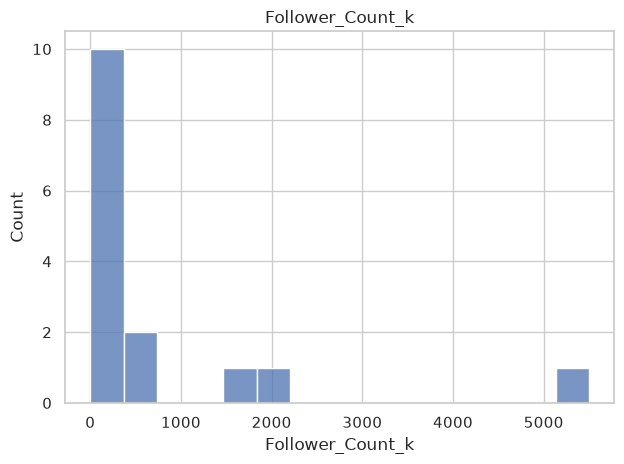

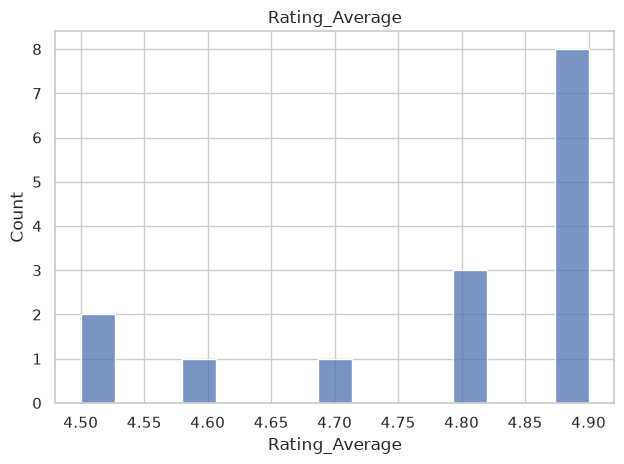

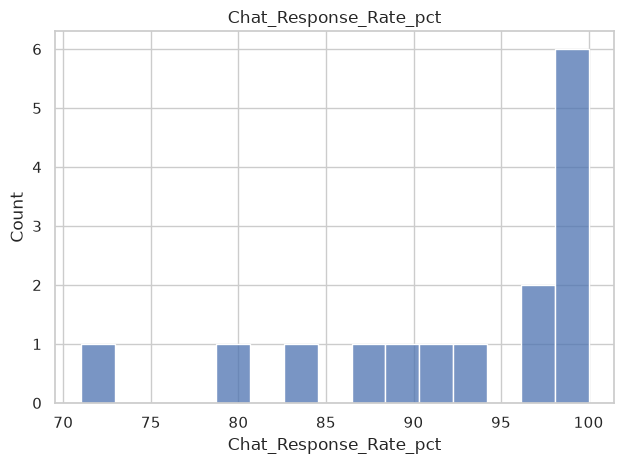

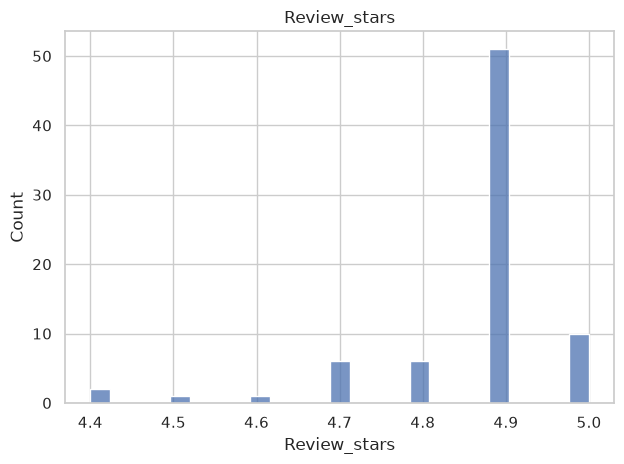

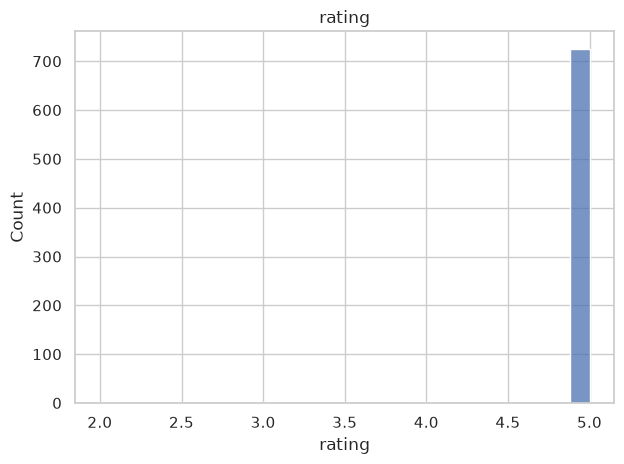

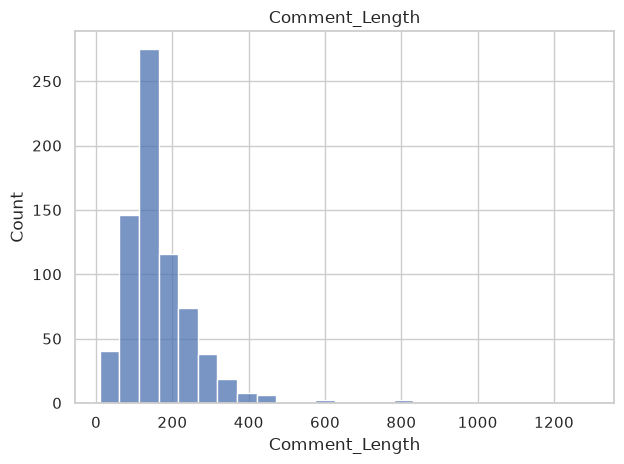

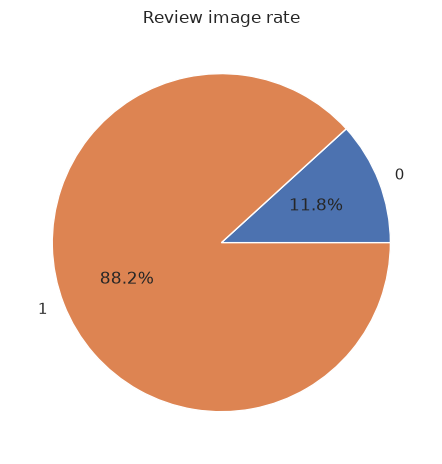

In [2]:
import os
os.environ.setdefault("MPLCONFIGDIR", str(OUTPUT / ".matplotlib"))
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

shops = pd.read_csv(PROCESSED / "shops_clean.csv")
products = pd.read_csv(PROCESSED / "products_clean.csv")
reviews = pd.read_csv(PROCESSED / "reviews_clean.csv")
sns.set_theme(style="whitegrid")

def save(fig, name):
    fig.tight_layout(); fig.savefig(OUTPUT / "figures" / name, dpi=160, bbox_inches="tight"); plt.show(); plt.close(fig)
def histogram(frame, column, name):
    values = frame[column].dropna()
    if values.empty: print(f"SKIP {column}: no observed values"); return
    fig, ax = plt.subplots(); sns.histplot(values, bins=min(25,max(5,len(values))), ax=ax); ax.set_title(column); save(fig,name)

for frame, column, name in [(shops,"Follower_Count_k","followers.png"),(shops,"Rating_Average","shop_rating.png"),(shops,"Chat_Response_Rate_pct","response_rate.png"),(products,"Review_stars","product_rating.png"),(reviews,"rating","review_rating.png"),(reviews,"Comment_Length","comment_length.png")]: histogram(frame,column,name)
if not reviews["has_image"].dropna().empty:
    fig, ax = plt.subplots(); reviews["has_image"].value_counts().sort_index().plot.pie(autopct="%1.1f%%", ax=ax); ax.set_ylabel(""); ax.set_title("Review image rate"); save(fig,"has_image.png")

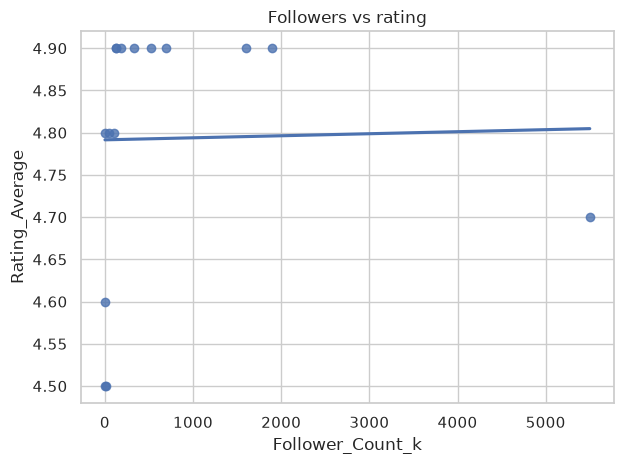

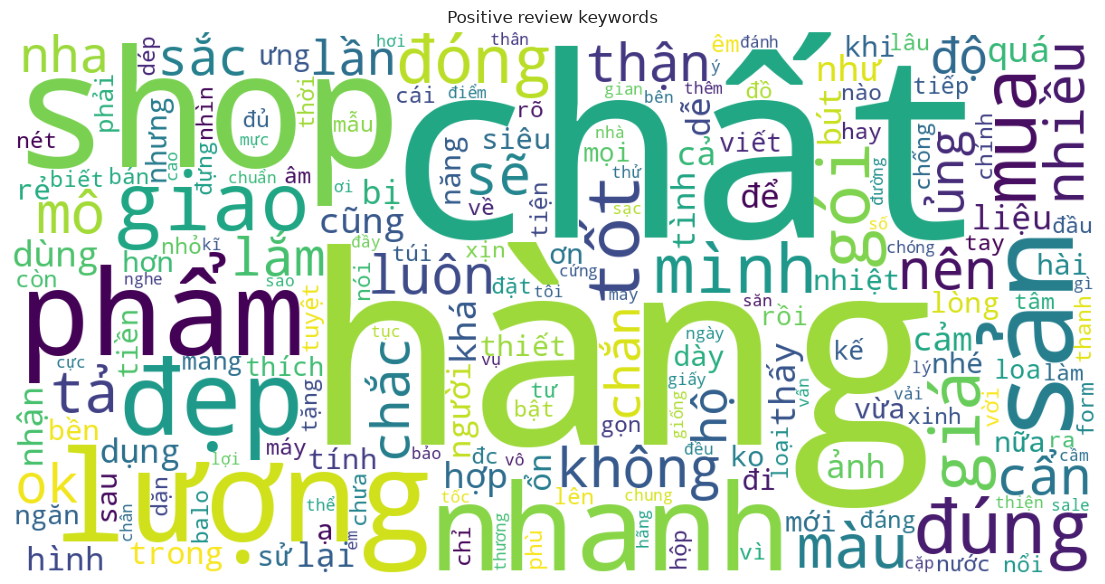

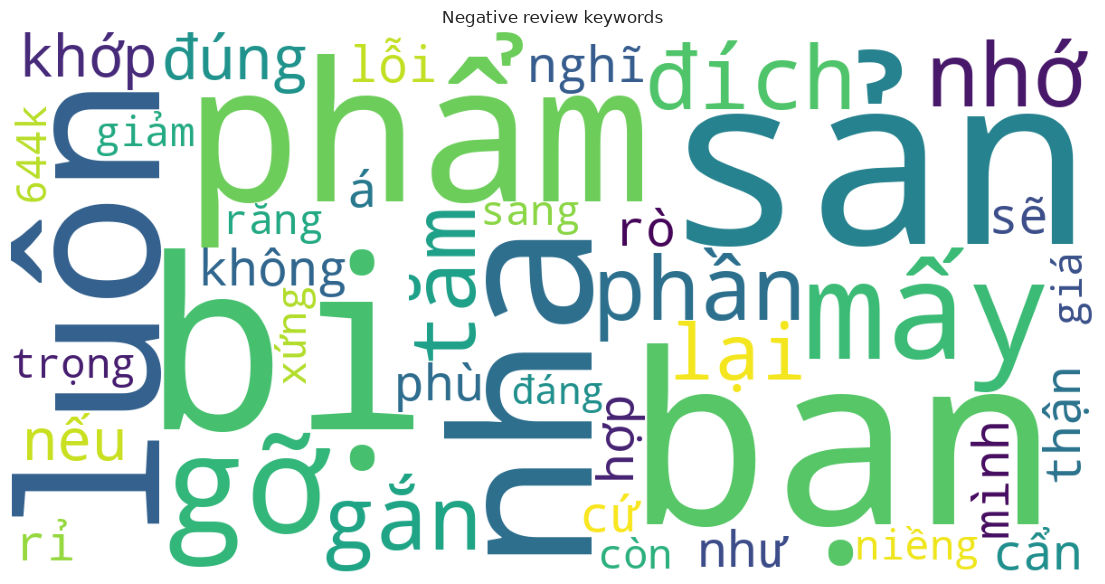

,Metric,Value
0,Total Shops,15.000000
1,Total Products,100.000000
2,Total Reviews,731.000000
3,Average Review Rating,4.984952
4,Image Rate,0.882353
5,Observed Units Sold,NaN


,Shop_ID,Shop_Name,Shop_type,Years_Active,Is_Online_Now,Total_Products,Follower_Count_k,Rating_Average,Total_Ratings_k,Chat_Response_Rate_pct,Has_Voucher,Target_Label,Time_Collected,Sales,Product_Count,Review_Count,Review_Image_Rate
0,01_001,Maison Online,Shopee Mall,6,NaN,11600,104.7,4.8,8.9,87,1.0,NaN,2026-09-27,NaN,10,31,0.612903
1,01_002,AstroMazing Official Store,Shopee Mall,6,NaN,98,129.9,4.9,108.2,94,1.0,NaN,2026-09-27,NaN,10,50,1.000000
2,01_003,Camelia Brand,Shopee Mall,7,NaN,90,525.1,4.9,132.4,100,NaN,NaN,2026-09-27,NaN,10,50,1.000000
3,01_004,Hoàng Phúc International,Shopee Mall,9,NaN,101,181.3,4.9,55.6,100,1.0,NaN,2026-09-27,NaN,10,50,0.920000
4,01_005,Lock&Lock Official Store (Cửa hàng chính hãng),Shopee Mall,9,NaN,552,1600.0,4.9,711.8,100,1.0,NaN,2026-09-27,NaN,10,50,0.920000
5,01_006,Ugreen Official Shop,Shopee Mall,6,NaN,1100,694.9,4.9,279.6,100,NaN,NaN,2026-09-28,NaN,5,50,1.000000
6,01_007,BAMA.BAG,Shopee Mall,8,NaN,130,330.2,4.9,47.2,99,NaN,NaN,2026-09-28,NaN,5,50,0.860000
7,01_008,SMART HOUSEHOLD,Shopee Mall,5,NaN,37,1.2,4.5,8.9,83,NaN,NaN,2026-09-28,NaN,5,50,0.460000
8,01_009,Gia Dụng Việt_123,Shop thường,5,NaN,52,10.2,4.5,10.0,80,NaN,NaN,2026-09-28,NaN,5,50,0.840000
9,01_010,Shop Mẹ Gold1,Shop thường,5,NaN,762,131.1,4.9,471.8,100,NaN,NaN,2026-09-28,NaN,5,50,0.900000


In [3]:
def scatter(x, y, name, title):
    if x not in shops or y not in shops or shops[[x,y]].dropna().empty: return
    fig, ax = plt.subplots(); sns.regplot(data=shops, x=x, y=y, ci=None, ax=ax); ax.set_title(title); save(fig,name)
scatter("Rating_Average","Sales","rating_sales.png","Rating vs observed sales")
scatter("Chat_Response_Rate_pct","Conversion_Rate_pct","response_conversion.png","Response rate vs conversion")
scatter("Follower_Count_k","Rating_Average","follower_rating.png","Followers vs rating")

for label in ["positive","negative"]:
    text = " ".join(reviews.loc[reviews["Sentiment_Label"] == label, "review_clean"].dropna().astype(str))
    if text.strip():
        cloud = WordCloud(width=1200,height=600,background_color="white",collocations=False).generate(text)
        fig, ax = plt.subplots(figsize=(12,6)); ax.imshow(cloud); ax.axis("off"); ax.set_title(f"{label.title()} review keywords"); save(fig,f"wordcloud_{label}.png")

observed_units = products["units_sold"].sum(min_count=1) if "units_sold" in products else np.nan
summary = pd.DataFrame({"Metric":["Total Shops","Total Products","Total Reviews","Average Review Rating","Image Rate","Observed Units Sold"],"Value":[len(shops),len(products),len(reviews),reviews["rating"].mean(),reviews["has_image"].mean(),observed_units]})
shop_eda = shops.copy()
shop_eda["Product_Count"] = shop_eda["Shop_ID"].map(products.groupby("Shop_ID").size()).fillna(0)
shop_eda["Review_Count"] = shop_eda["Shop_ID"].map(reviews.groupby("Shop_ID").size()).fillna(0)
shop_eda["Review_Image_Rate"] = shop_eda["Shop_ID"].map(reviews.groupby("Shop_ID")["has_image"].mean())
summary.to_csv(OUTPUT / "powerbi" / "kpi_summary.csv", index=False)
shop_eda.to_csv(OUTPUT / "powerbi" / "shop_eda_summary.csv", index=False)
reviews.groupby(["Shop_ID","Sentiment_Label"], observed=True).size().rename("Review_Count").reset_index().to_csv(OUTPUT / "powerbi" / "sentiment_summary.csv", index=False)
display(summary); display(shop_eda)